Author: Jessica Xu

This code performs Exploratory Data Analysis (EDA) on merged Google Places and Yelp datasets... TBA

AI used only for debugging and minor modifications.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load dataset
BASE_DIR = os.getcwd()

FILENAME = "gp_yelp_matched_cleaned.csv"

FILEPATH = os.path.join(BASE_DIR, FILENAME)

gp_yelp = pd.read_csv(FILEPATH)

print("rows:", len(gp_yelp))

rows: 1850


### EDA

In [3]:
gp_yelp.shape, gp_yelp.columns

((1850, 75),
 Index(['gp_place_id', 'yelp_business_id', 'dist_m', 'gp_name_norm_x',
        'gp_specific_address_x', 'gp_zipcode_x', 'yelp_name_norm_x',
        'yelp_address1_x', 'yelp_zip_code_x', 'name_sim', 'addr_sim',
        'dist_score', 'score', 'gp_name', 'gp_address', 'gp_latitude',
        'gp_longitude', 'gp_price_range_raw', 'gp_price_level', 'gp_rating',
        'gp_review_count', 'gp_types', 'gp_primary_type', 'gp_business_status',
        'gp_regular_opening_hours_raw', 'gp_takeout', 'gp_delivery',
        'gp_dine_in', 'gp_reservable', 'gp_query_lat', 'gp_query_lon',
        'gp_specific_address_y', 'gp_city', 'gp_zipcode_y', 'gp_country',
        'gp_name_norm_y', 'gp_price_level_1to4', 'gp_price_start',
        'gp_price_end', 'gp_open_days_per_week', 'gp_total_open_minutes_week',
        'gp_avg_open_minutes_open_day', 'gp_weekend_open_minutes',
        'gp_open_late_minutes', 'gp_takeout_d', 'gp_delivery_d', 'gp_dine_in_d',
        'gp_reservable_d', 'yelp_name', '

In [4]:
gp_yelp.head()

,gp_place_id,yelp_business_id,dist_m,gp_name_norm_x,gp_specific_address_x,gp_zipcode_x,yelp_name_norm_x,yelp_address1_x,yelp_zip_code_x,name_sim,...,yelp_pickup_d,yelp_restaurant_reservation_d,res_rating,res_review_count,res_takeout,res_delivery,res_dine_in,res_reservable,res_pickup,res_price_level
0,ChIJja3R4OEtDogRrc5n8J9LTE0,PFAg72nWgzNzfs9r7BR-FQ,0.0,raising cane s chicken fingers,2 N Michigan Ave,60602,raising cane s chicken fingers,2 N Michigan Ave,60602,100.0,...,0,0,4.234466,1236,1,0,1,0,0,1.0
1,ChIJfd-z_P4tDogRV7147ELK0ns,5CPMzmua1XTEb-xI9os8ig,0.0,falco s pizza,2806 W 40th Pl,60632,falco s pizza,2806 W 40th Pl,60632,100.0,...,1,0,4.067439,1726,1,1,1,0,1,2.0
2,ChIJwb3X2rLTD4gRl5-rajcHWzw,1idYafjrRj4GsMhzLExuCw,0.0,the bakehouse chicago,3915 N Sheridan Rd,60613,the bakehouse chicago,3915 N Sheridan Rd,60613,100.0,...,1,0,4.577654,179,1,1,1,0,1,1.0
3,ChIJw03pYWYtDogRD5w6F7LhzFo,uQ8fHNvR5OpT_rtLhCxlrA,0.0,chipotle mexican grill,3125 S Ashland Ave,60608,chipotle mexican grill,3125 S Ashland Ave,60608,100.0,...,0,0,2.711594,138,1,1,1,0,0,1.0
4,ChIJ2frCB0gvDogRXA7tF8yFtiU,WNiybL5YoT6kAsmXFkKX2Q,0.0,fh jerkgod,111 E 51st St,60615,fh jerkgod,111 E 51st St,60615,100.0,...,1,0,4.573016,252,1,1,1,0,1,2.0


In [5]:
gp_yelp.isnull().sum().sort_values(ascending=False)

yelp_price_level_1to4    543
yelp_price               543
gp_reservable            425
gp_price_end             229
yelp_transactions        228
                        ... 
gp_zipcode_x               0
score                      0
gp_takeout_d               0
gp_delivery_d              0
gp_place_id                0
Length: 75, dtype: int64

In [6]:
gp_yelp.dtypes

gp_place_id               object
yelp_business_id          object
dist_m                   float64
gp_name_norm_x            object
gp_specific_address_x     object
                          ...   
res_delivery               int64
res_dine_in                int64
res_reservable             int64
res_pickup                 int64
res_price_level          float64
Length: 75, dtype: object

In [7]:
gp_yelp["res_price_level"].value_counts(dropna=False).sort_index()

res_price_level
1.0    614
2.0    988
3.0     79
4.0     17
NaN    152
Name: count, dtype: int64

In [8]:
res_cols = ["res_rating", "res_review_count", "res_price_level", "res_takeout", "res_delivery", "res_dine_in", "res_reservable", "res_pickup"]
gp_yelp[res_cols].head()

,res_rating,res_review_count,res_price_level,res_takeout,res_delivery,res_dine_in,res_reservable,res_pickup
0,4.234466,1236,1.0,1,0,1,0,0
1,4.067439,1726,2.0,1,1,1,0,1
2,4.577654,179,1.0,1,1,1,0,1
3,2.711594,138,1.0,1,1,1,0,0
4,4.573016,252,2.0,1,1,1,0,1


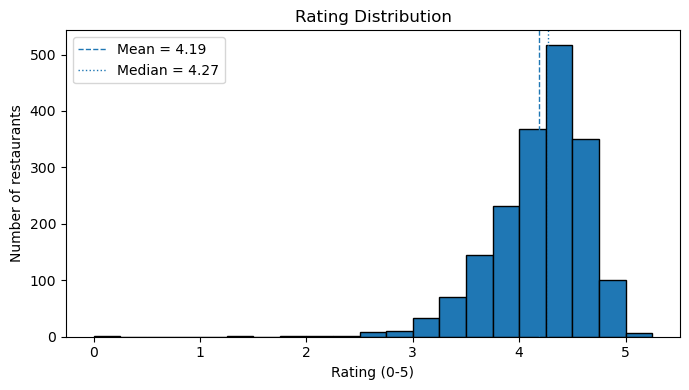

In [9]:
# distribution of rating

r = pd.to_numeric(gp_yelp["res_rating"], errors="coerce").dropna()

bins = np.arange(0, 5.5, 0.25)
plt.figure(figsize=(7, 4))
plt.hist(r, bins=bins, edgecolor="black")
plt.axvline(r.mean(), linestyle="--", linewidth=1, label=f"Mean = {r.mean():.2f}")
plt.axvline(r.median(), linestyle=":", linewidth=1, label=f"Median = {r.median():.2f}")

plt.title("Rating Distribution")
plt.xlabel("Rating (0-5)")
plt.ylabel("Number of restaurants")
plt.legend()
plt.tight_layout()
plt.show()

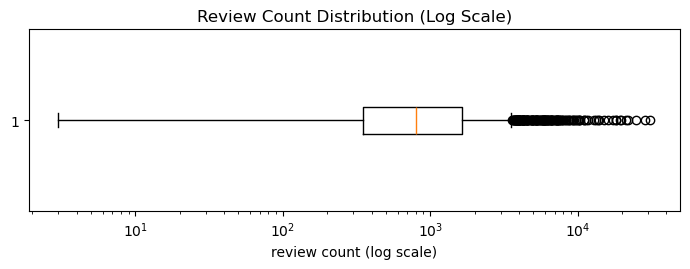

In [10]:
# distribution  of review count (log)

rc = pd.to_numeric(gp_yelp["res_review_count"], errors="coerce")
rc = rc[(rc.notna()) & (rc > 0)]

plt.figure(figsize=(7, 2.8))
plt.boxplot(rc, vert=False, showfliers=True)
plt.xscale("log")

plt.title("Review Count Distribution (Log Scale)")
plt.xlabel("review count (log scale)")
plt.tight_layout()
plt.show()

The distribution of merged review counts is highly right-skewed on a log scale, indicating that most restaurants have relatively moderate numbers of reviews while a small number have extremely large review volumes. This suggests inequality in online visibility and customer engagement across restaurants.

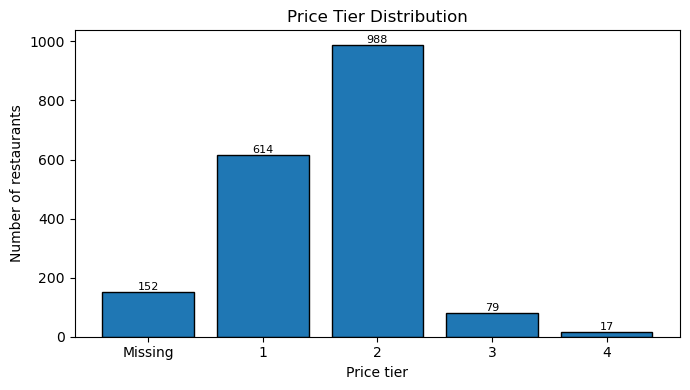

In [11]:
# price level distribution

p = pd.to_numeric(gp_yelp["res_price_level"], errors="coerce")

missing_ct = int(p.isna().sum())
ct1 = int((p == 1).sum())
ct2 = int((p == 2).sum())
ct3 = int((p == 3).sum())
ct4 = int((p == 4).sum())

x_labels = ["Missing", "1", "2", "3", "4"]
y_vals = [missing_ct, ct1, ct2, ct3, ct4]

plt.figure(figsize=(7, 4))
bars = plt.bar(x_labels, y_vals, edgecolor="black")

for b in bars:
    h = b.get_height()
    if h > 0:
        plt.text(b.get_x() + b.get_width()/2, h, f"{int(h)}",
                 ha="center", va="bottom", fontsize=8)

plt.title("Price Tier Distribution")
plt.xlabel("Price tier")
plt.ylabel("Number of restaurants")
plt.tight_layout()
plt.show()

Yelp helps balance Google Places by providing an additional source of price and service data, allowing missing tiers or service signals in one platform to be filled by the other and reducing overall missingness in the merged dataset. The small number of tier-4 restaurants likely reflects both real scarcity and coverage issues: expensive venues are less common and may be less consistently labeled with price tiers, and they can also be harder to match across platforms due to branding differences and missing/ambiguous metadata.

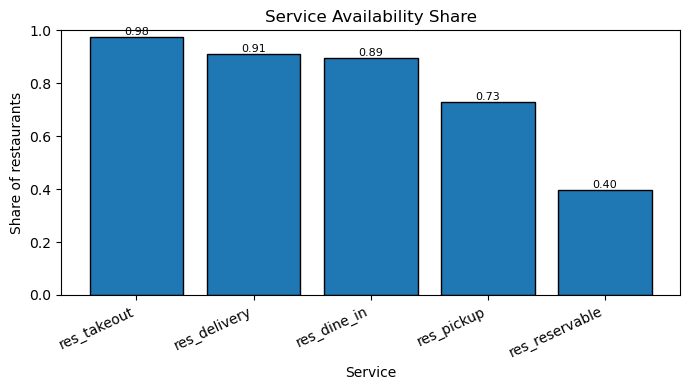

In [12]:
# service availability distribution

service_cols = ["res_takeout", "res_delivery", "res_dine_in", "res_reservable", "res_pickup"]
service_share = (gp_yelp[service_cols].apply(pd.to_numeric, errors="coerce").fillna(0).clip(0, 1).mean().sort_values(ascending=False))

plt.figure(figsize=(7, 4))
bars = plt.bar(service_share.index, service_share.values, edgecolor="black")

for b in bars:
    h = b.get_height()
    if h > 0:
        plt.text(b.get_x() + b.get_width()/2, h, f"{h:.2f}",
                 ha="center", va="bottom", fontsize=8)

plt.title("Service Availability Share")
plt.xlabel("Service")
plt.ylabel("Share of restaurants")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

/var/folders/lm/wvqh87x93hs7jfg66h8zq72c0000gn/T/ipykernel_7431/4286192450.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=["1", "2", "3", "4"], showfliers=False)


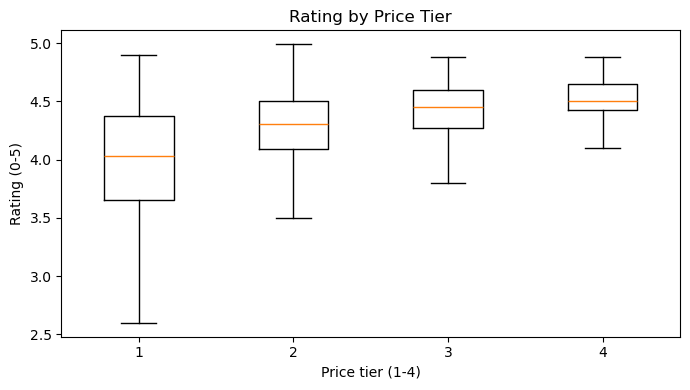

In [13]:
# rating by price tier

plot_df = gp_yelp[["res_rating", "res_price_level"]].copy()
plot_df["res_rating"] = pd.to_numeric(plot_df["res_rating"], errors="coerce")
plot_df["res_price_level"] = pd.to_numeric(plot_df["res_price_level"], errors="coerce")
plot_df = plot_df.dropna(subset=["res_rating", "res_price_level"])
plot_df = plot_df[plot_df["res_price_level"].isin([1, 2, 3, 4])]

groups = [plot_df.loc[plot_df["res_price_level"] == k, "res_rating"].values for k in [1, 2, 3, 4]]

plt.figure(figsize=(7, 4))
plt.boxplot(groups, labels=["1", "2", "3", "4"], showfliers=False)

plt.title("Rating by Price Tier")
plt.xlabel("Price tier (1-4)")
plt.ylabel("Rating (0-5)")
plt.tight_layout()
plt.show()

The median restaurant rating increases steadily from price tier 1 to tier 4, suggesting that higher-priced restaurants tend to receive higher ratings on average. At the same time, lower-priced restaurants show greater variability in ratings, while higher-priced tiers have more tightly clustered and consistently high scores.